In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from scripts.mask_convert import mask_netcdf

In [2]:
UTCI_LEVELS = {
    0: (float("-inf"), -40, "Estrés por frío extremo"),
    1: (-40, -27, "Estrés por frío muy fuerte"),
    2: (-27, -13, "Estrés por frío fuerte"),
    3: (-13, 0, "Estrés por frío moderado"),
    4: (0, 9, "Estrés por frío ligero"),
    5: (9, 26, "Sin estrés térmico"),
    6: (26, 32, "Estrés por calor moderado"),
    7: (32, 38, "Estrés por calor fuerte"),
    8: (38, 46, "Estrés por calor muy fuerte"),
    9: (46, float("inf"), "Estrés por calor extremo"),
}

DATES_SEASONS = {
    "Invierno": (12, 21, 3, 20),
    "Primavera": (3, 21, 6, 20),
    "Verano": (6, 21, 9, 22),
    "Otoño": (9, 23, 12, 20),
}

In [3]:
def categorize(utci, levels):
    """Asigna a cada punto (tiempo, espacio) el código de categoría UTCI."""
    categories = xr.full_like(utci, float("nan"))
    for category, (lim_inf, lim_sup, _) in levels.items():
        mask = (utci > lim_inf) & (utci <= lim_sup)
        categories = xr.where(mask, category, categories)
    return categories.astype("float32")


In [4]:
def percentage_from_categories(categories, levels, dim):
    """Calcula el % de tiempo en cada categoría, colapsando la dimensión `dim`."""
    valid_count = categories.notnull().sum(dim)

    counts = xr.concat(
        [(categories == category).sum(dim) for category in levels],
        dim="category",
    )
    counts = counts.assign_coords(category=list(levels.keys()))

    stress_percentage = counts / valid_count * 100

    labels = [info[2] for info in levels.values()]
    stress_percentage = stress_percentage.assign_coords(
        category_label=("category", labels)
    )
    return stress_percentage

In [5]:
def calculate_thermal_stress_percentage(
    netcdf_path,
    shapefile_path,
    levels=UTCI_LEVELS,
    dim="time",
    period="anual",
    rangos_estaciones=DATES_SEASONS,
):
    """
    Enmascara un NetCDF de UTCI con un shapefile y calcula, para cada punto
    espacial, el porcentaje de tiempo que el UTCI cae en cada categoría de
    estrés térmico, de forma anual o estacional.

    Parameters
    ----------
    netcdf_path : str
        Ruta al archivo NetCDF con los datos de UTCI (en grados Celsius).
    shapefile_path : str
        Ruta al shapefile/gpkg usado para enmascarar la zona de interés.
    levels : dict
        Diccionario {codigo: (lim_inf, lim_sup, etiqueta)} con los límites
        de cada categoría de estrés térmico. Por defecto usa UTCI_LEVELS.
    dim : str
        Nombre de la dimensión temporal (normalmente "time").
    period : str
        "anual": todo el rango de tiempo junto.
        "estacional": agrupa por temporadas definidas en `rangos_estaciones`
        usando rangos de (mes, dia). Sirve para cualquier año sin
        modificar la función, y cruza el fin de año automáticamente
        (ej. invierno: Dic 21 -> Mar 20).
    rangos_estaciones : dict
        Diccionario {nombre_estacion: (mes_inicio, dia_inicio, mes_fin, dia_fin)}.
        Por defecto usa DATES_SEASONS.

    Returns
    -------
    xr.Dataset
        - period="anual": dims espaciales + "category".
        - period="estacional": dims espaciales + "category" + "season".
    """
    utci = mask_netcdf(netcdf_path=netcdf_path, shapefile_path=shapefile_path)
    categories = categorize(utci, levels)

    if period == "anual":
        return percentage_from_categories(categories, levels, dim)

    elif period == "estacional":
        tiempos = categories[dim].dt
        clave_actual = tiempos.month * 100 + tiempos.day

        resultados = []
        nombres = []

        for nombre, (mes_ini, dia_ini, mes_fin, dia_fin) in rangos_estaciones.items():
            clave_ini = mes_ini * 100 + dia_ini
            clave_fin = mes_fin * 100 + dia_fin

            if clave_ini <= clave_fin:
                mascara = (clave_actual >= clave_ini) & (clave_actual <= clave_fin)
            else:
                mascara = (clave_actual >= clave_ini) | (clave_actual <= clave_fin)

            subconjunto = categories.where(mascara, drop=True)

            if subconjunto.sizes[dim] == 0:
                continue

            pct = percentage_from_categories(subconjunto, levels, dim)
            resultados.append(pct)
            nombres.append(nombre)

        stress_percentage = xr.concat(resultados, dim="season")
        stress_percentage = stress_percentage.assign_coords(season=nombres)
        return stress_percentage

    else:
        raise ValueError(
            f"period debe ser 'anual' o 'estacional', recibido: {period!r}"
        )



In [ ]:
utci_anual = calculate_thermal_stress_percentage(
    netcdf_path="../data/001_raw/ECMWF_utci_2022_mexico_anual.nc",
    shapefile_path="../data/001_raw/mexico_mask.gpkg",
    period="anual",
)

In [ ]:
utci_estacional = calculate_thermal_stress_percentage(
    netcdf_path="../data/001_raw/ECMWF_utci_2022_mexico_anual.nc",
    shapefile_path="../data/001_raw/mexico_mask.gpkg",
    period="estacional",
)
utci_estacional

<xarray.Dataset> Size: 3MB
Dimensions:         (season: 4, category: 10, lat: 77, lon: 133)
Coordinates:
  * season          (season) <U9 144B 'Invierno' 'Primavera' 'Verano' 'Otoño'
  * category        (category) int64 80B 0 1 2 3 4 5 6 7 8 9
    category_label  (category) <U27 1kB 'Estrés por frío extremo' ... 'Estrés...
  * lat             (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
  * lon             (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.25 -86.0
    spatial_ref     int64 8B 0
Data variables:
    utci            (season, category, lat, lon) float64 3MB nan nan ... nan nan

In [8]:
utci_anual= utci_anual["utci"]
utci_estacional= utci_estacional["utci"]

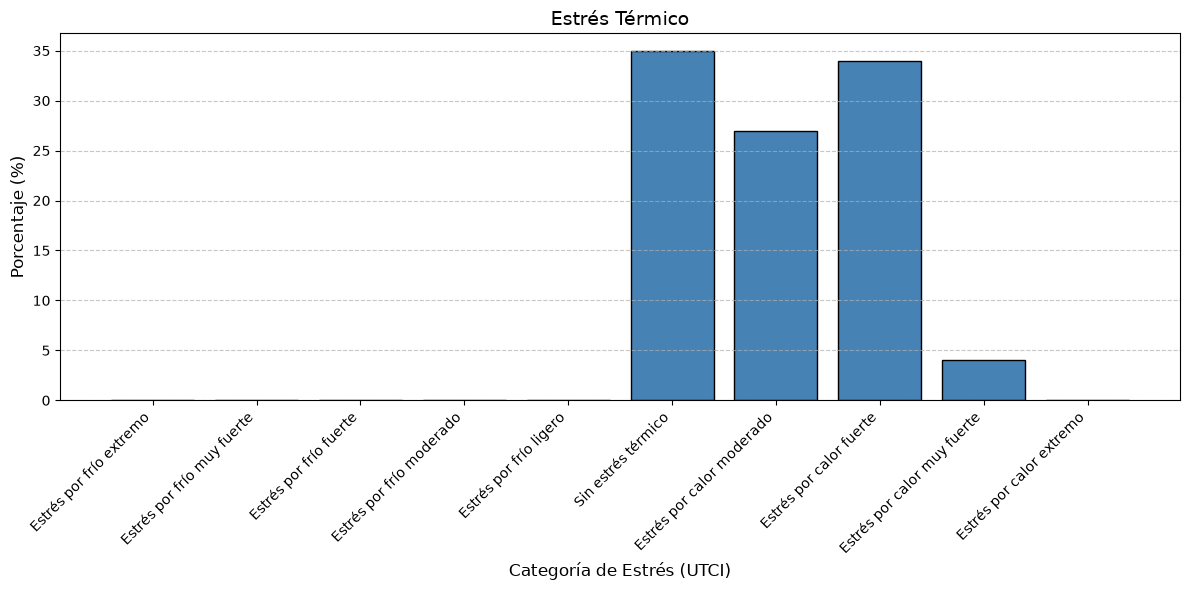

In [9]:
punto_prueba = utci_anual.sel(lat=14.75, lon=-92.25, method="nearest") 	

fig, ax = plt.subplots(figsize=(12, 6))  

ax.bar(
    punto_prueba["category_label"].values,  
    punto_prueba.values,           
    color="steelblue", 
    edgecolor="black"
)

ax.set_title("Estrés Térmico", fontsize=14)
ax.set_ylabel("Porcentaje (%)", fontsize=12)
ax.set_xlabel("Categoría de Estrés (UTCI)", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.7)  

plt.tight_layout() 
plt.show()


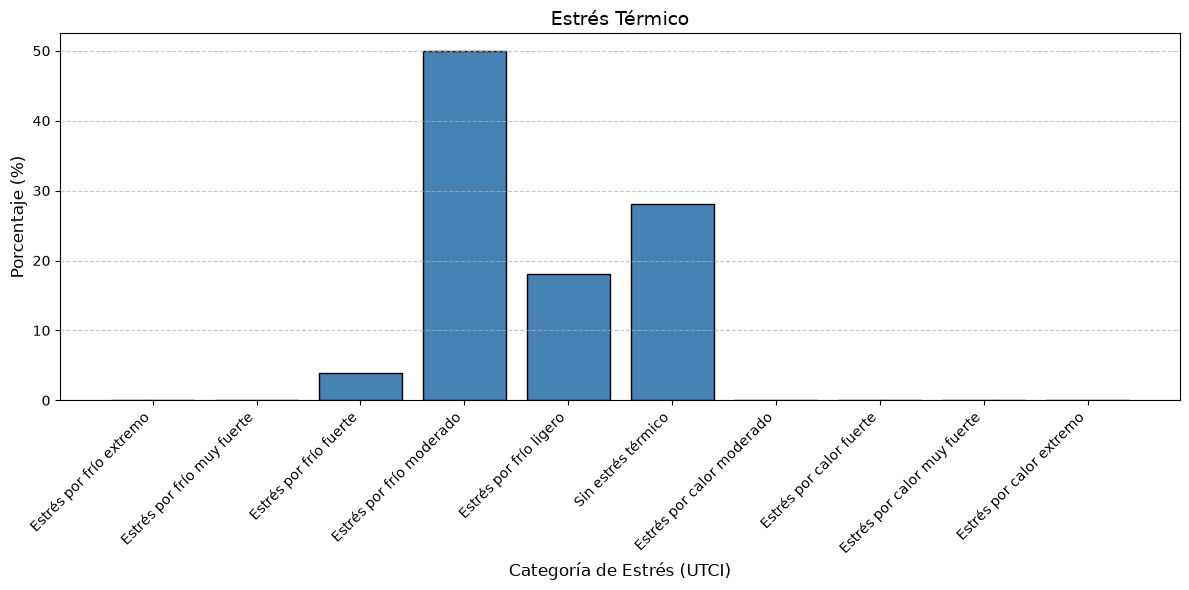

In [10]:
# Invierno en la Rosilla, Durango
punto_prueba = utci_estacional.sel(
    lat=25.92, lon=-106.18, method="nearest"
).sel(season="Invierno")  # <- cambia aquí la temporada: "DJF", "MAM", "JJA" o "SON"

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    punto_prueba["category_label"].values,
    punto_prueba.values,
    color="steelblue",
    edgecolor="black"
)

ax.set_title("Estrés Térmico", fontsize=14)
ax.set_ylabel("Porcentaje (%)", fontsize=12)
ax.set_xlabel("Categoría de Estrés (UTCI)", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

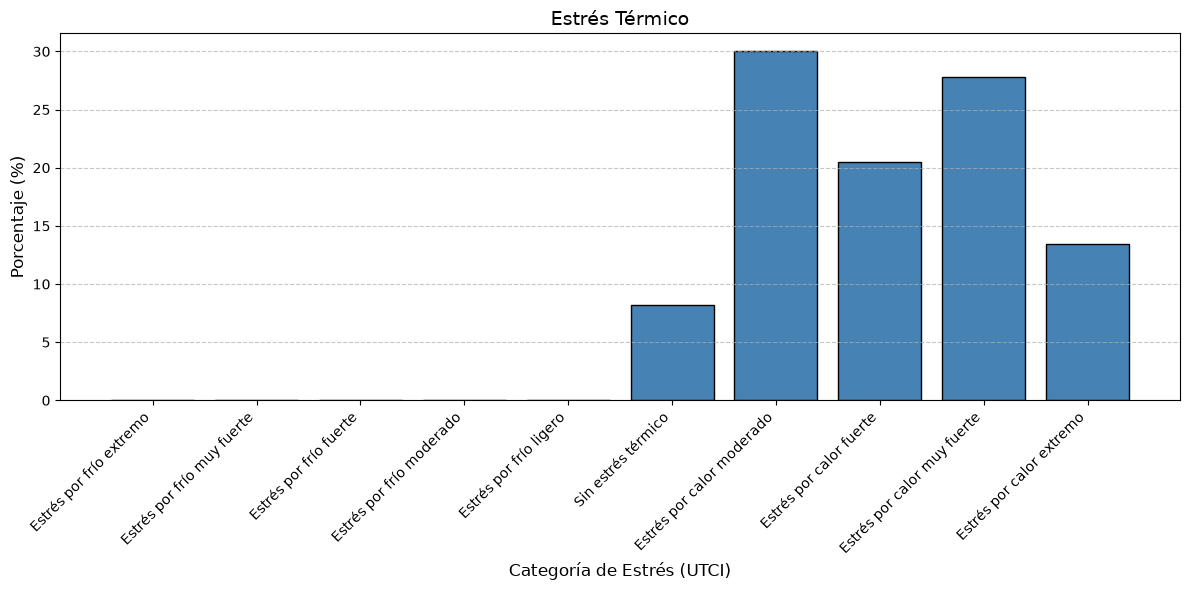

In [11]:
# Verano en Mexicali, Baja California
punto_prueba = utci_estacional.sel(
    lat=32.5, lon=-115.2, method="nearest"
).sel(season="Verano")  # <- cambia aquí la temporada: "DJF", "MAM", "JJA" o "SON"

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    punto_prueba["category_label"].values,
    punto_prueba.values,
    color="steelblue",
    edgecolor="black"
)

ax.set_title("Estrés Térmico", fontsize=14)
ax.set_ylabel("Porcentaje (%)", fontsize=12)
ax.set_xlabel("Categoría de Estrés (UTCI)", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [12]:
# --- Comprobación matemática de porcentajes por estación ---
promedio_estacional = utci_estacional.mean(dim=["lat", "lon"], skipna=True)
seasons = promedio_estacional["season"].values

print("--- VERIFICACIÓN DE SUMAS POR TEMPORADA ---")
for season in seasons:
    # Selecciona los valores de la temporada actual y los suma
    suma_temporada = float(promedio_estacional.sel(season=season).sum())
    print(f"Suma de porcentajes para {season}: {suma_temporada:.2f}%")

--- VERIFICACIÓN DE SUMAS POR TEMPORADA ---
Suma de porcentajes para Invierno: 100.00%
Suma de porcentajes para Primavera: 100.00%
Suma de porcentajes para Verano: 100.00%
Suma de porcentajes para Otoño: 100.00%


In [ ]:
utci = mask_netcdf(
    netcdf_path="../data/001_raw/ECMWF_utci_2022_mexico_anual.nc",
    shapefile_path="../data/001_raw/mexico_mask.gpkg",
)["utci"]

tiempos = utci["time"].dt
clave_actual = tiempos.month * 100 + tiempos.day

for nombre, (mes_ini, dia_ini, mes_fin, dia_fin) in DATES_SEASONS.items():
    clave_ini = mes_ini * 100 + dia_ini
    clave_fin = mes_fin * 100 + dia_fin

    if clave_ini <= clave_fin:
        mascara = (clave_actual >= clave_ini) & (clave_actual <= clave_fin)
    else:
        mascara = (clave_actual >= clave_ini) | (clave_actual <= clave_fin)

    fechas_incluidas = utci["time"].where(mascara, drop=True)
    print(f"{nombre}: {fechas_incluidas.sizes['time']} horas")
    print(f"  Primera fecha: {fechas_incluidas.min().values}")
    print(f"  Última fecha:  {fechas_incluidas.max().values}")
    print()

Invierno: 2160 horas
  Primera fecha: 2022-01-01T00:00:00.000000000
  Última fecha:  2022-12-31T23:00:00.000000000

Primavera: 2208 horas
  Primera fecha: 2022-03-21T00:00:00.000000000
  Última fecha:  2022-06-20T23:00:00.000000000

Verano: 2256 horas
  Primera fecha: 2022-06-21T00:00:00.000000000
  Última fecha:  2022-09-22T23:00:00.000000000

Otoño: 2136 horas
  Primera fecha: 2022-09-23T00:00:00.000000000
  Última fecha:  2022-12-20T23:00:00.000000000



In [ ]:
utci_anual.to_netcdf(
    "../data/002_processed/stress_utci_anual_2022.nc",
    engine="netcdf4",
)

In [ ]:
utci_estacional.to_netcdf(
    "../data/002_processed/stress_utci_seasonal_2022.nc",
    engine="netcdf4",
)

In [ ]:
utci = xr.open_dataset("../data/002_processed/stress_utci_anual_2022.nc")
utci

<xarray.Dataset> Size: 822kB
Dimensions:         (category: 10, lat: 77, lon: 133)
Coordinates:
  * category        (category) int64 80B 0 1 2 3 4 5 6 7 8 9
    category_label  (category) <U27 1kB ...
  * lat             (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
  * lon             (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.25 -86.0
    spatial_ref     int64 8B ...
Data variables:
    utci            (category, lat, lon) float64 819kB ...

In [ ]:
utci_estacional = xr.open_dataset("../data/002_processed/stress_utci_seasonal_2022.nc")
utci_estacional

<xarray.Dataset> Size: 3MB
Dimensions:         (season: 4, category: 10, lat: 77, lon: 133)
Coordinates:
  * season          (season) <U9 144B 'Invierno' 'Primavera' 'Verano' 'Otoño'
  * category        (category) int64 80B 0 1 2 3 4 5 6 7 8 9
    category_label  (category) <U27 1kB ...
  * lat             (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
  * lon             (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.25 -86.0
    spatial_ref     int64 8B ...
Data variables:
    utci            (season, category, lat, lon) float64 3MB ...